# 06 Model Evaluation and Comparison

This notebook compares the two machine learning models trained for the AgriCredit Resilience project:

1. Decision Tree
2. Logistic Regression

The target feature is:

`financial_vulnerability`

The goal is to compare the models using evaluation metrics, confusion matrices, ROC-AUC, and interpretability.

This helps decide which model is more suitable for the final decision-support system.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

import joblib

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

ABT_PATH = PROCESSED_DATA_DIR / "farmer_vulnerability_abt.csv"
DECISION_TREE_MODEL_PATH = MODELS_DIR / "decision_tree_model.joblib"
LOGISTIC_REGRESSION_MODEL_PATH = MODELS_DIR / "logistic_regression_model.joblib"

ABT_PATH, DECISION_TREE_MODEL_PATH, LOGISTIC_REGRESSION_MODEL_PATH

(PosixPath('/Users/isaacaung/Desktop/agricredit-resilience/data/processed/farmer_vulnerability_abt.csv'),
 PosixPath('/Users/isaacaung/Desktop/agricredit-resilience/models/decision_tree_model.joblib'),
 PosixPath('/Users/isaacaung/Desktop/agricredit-resilience/models/logistic_regression_model.joblib'))

In [3]:
abt = pd.read_csv(ABT_PATH)

abt.head()

,household_id,state_region,township,household_size,female_headed_household,disability_present,displacement_status,monthly_income,has_debt,total_debt,...,cash_food_assistance_per_person,household_meb_requirement,income_to_meb_ratio,meb_gap,coverage_rate,coverage_gap_ratio,response_gap,number_of_partners_active,vulnerability_score,financial_vulnerability
0,HH00001,Magway,Magway,6,0,0,IDP,610149.0,1,851624,...,30000,330000,1.848936,280149.0,0.380,0.620,15359,21,3,1
1,HH00002,Ayeyarwady,Pathein,8,0,0,Resident,284061.0,1,801819,...,35000,440000,0.645593,-155939.0,0.424,0.576,56238,21,4,1
2,HH00003,Shan North,Lashio,4,0,0,Resident,50000.0,0,0,...,50000,240000,0.208333,-190000.0,0.607,0.393,9415,17,5,1
3,HH00004,Kayin,Hpa-An,4,0,0,Resident,101947.0,1,667989,...,40000,260000,0.392104,-158053.0,0.387,0.613,128076,20,3,1
4,HH00005,Kayin,Myawaddy,6,0,0,Returnee,675893.0,1,593253,...,40000,390000,1.733059,285893.0,0.387,0.613,128076,20,3,1


In [4]:
decision_tree_model = joblib.load(DECISION_TREE_MODEL_PATH)
logistic_regression_model = joblib.load(LOGISTIC_REGRESSION_MODEL_PATH)

print("Models loaded successfully.")

Models loaded successfully.


In [5]:
print(f"Rows: {abt.shape[0]}")
print(f"Columns: {abt.shape[1]}")

abt["financial_vulnerability"].value_counts().sort_index()

Rows: 1500
Columns: 44


financial_vulnerability
0    555
1    945
Name: count, dtype: int64

## Dataset and Model Loading Check

The final ABT and both saved models were loaded successfully.

The same ABT is used for both models so that the comparison is fair. The target feature is `financial_vulnerability`, where 0 means not financially vulnerable and 1 means financially vulnerable.

In [6]:
target_column = "financial_vulnerability"

feature_columns = [
    # Location/context
    "state_region",

    # Household characteristics
    "household_size",
    "female_headed_household",
    "disability_present",
    "displacement_status",

    # Financial features
    "monthly_income",
    "has_debt",
    "total_debt",
    "monthly_debt_repayment",
    "savings_duration_weeks",
    "debt_to_income_ratio",
    "monthly_debt_repayment_ratio",

    # Market access
    "market_access",

    # Agriculture features
    "is_farming_household",
    "main_crop",
    "farm_size_acres",
    "irrigation_access",
    "fertilizer_cost",
    "crop_damage_recent",

    # Coping and basic needs
    "rCSI_score",
    "basic_needs_score",

    # Market context
    "basic_food_basket_change_1y",
    "rice_price_change_1y",
    "fuel_price_change_1y",
    "market_disruption_score",
    "market_pressure_score",

    # MEB features
    "mpca_per_person",
    "household_meb_requirement",
    "income_to_meb_ratio",
    "meb_gap",

    # Assistance coverage
    "coverage_rate",
    "coverage_gap_ratio",
    "response_gap",
    "number_of_partners_active",
]

X = abt[feature_columns].copy()
y = abt[target_column]

X.head()

,state_region,household_size,female_headed_household,disability_present,displacement_status,monthly_income,has_debt,total_debt,monthly_debt_repayment,savings_duration_weeks,...,market_disruption_score,market_pressure_score,mpca_per_person,household_meb_requirement,income_to_meb_ratio,meb_gap,coverage_rate,coverage_gap_ratio,response_gap,number_of_partners_active
0,Magway,6,0,0,IDP,610149.0,1,851624,150329,1,...,1,91.4,55000,330000,1.848936,280149.0,0.380,0.620,15359,21
1,Ayeyarwady,8,0,0,Resident,284061.0,1,801819,95454,4,...,1,70.9,55000,440000,0.645593,-155939.0,0.424,0.576,56238,21
2,Shan North,4,0,0,Resident,50000.0,0,0,0,2,...,2,78.5,60000,240000,0.208333,-190000.0,0.607,0.393,9415,17
3,Kayin,4,0,0,Resident,101947.0,1,667989,60245,2,...,1,66.5,65000,260000,0.392104,-158053.0,0.387,0.613,128076,20
4,Kayin,6,0,0,Returnee,675893.0,1,593253,81094,1,...,1,66.5,65000,390000,1.733059,285893.0,0.387,0.613,128076,20


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")

print("\nTesting target distribution:")
print(y_test.value_counts().sort_index())

Training rows: 1200
Testing rows: 300

Testing target distribution:
financial_vulnerability
0    111
1    189
Name: count, dtype: int64


## Fair Evaluation Setup

Both models are evaluated on the same test set. This makes the comparison fair because the Decision Tree and Logistic Regression models are tested on the exact same 300 household records.

In [8]:
# Decision Tree predictions
dt_pred = decision_tree_model.predict(X_test)
dt_proba = decision_tree_model.predict_proba(X_test)[:, 1]

# Logistic Regression predictions
lr_pred = logistic_regression_model.predict(X_test)
lr_proba = logistic_regression_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [9]:
def evaluate_model(model_name, y_true, y_pred, y_proba):
    """Return common evaluation metrics for a model."""

    cm = confusion_matrix(y_true, y_pred)

    return {
        "model_name": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1_score": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "true_negative": cm[0, 0],
        "false_positive": cm[0, 1],
        "false_negative": cm[1, 0],
        "true_positive": cm[1, 1],
    }

In [10]:
evaluation_results = [
    evaluate_model(
        model_name="Decision Tree",
        y_true=y_test,
        y_pred=dt_pred,
        y_proba=dt_proba,
    ),
    evaluate_model(
        model_name="Logistic Regression",
        y_true=y_test,
        y_pred=lr_pred,
        y_proba=lr_proba,
    ),
]

comparison_df = pd.DataFrame(evaluation_results)

comparison_df_rounded = comparison_df.copy()

metric_cols = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
]

comparison_df_rounded[metric_cols] = comparison_df_rounded[metric_cols].round(4)

comparison_df_rounded

,model_name,accuracy,precision,recall,f1_score,roc_auc,true_negative,false_positive,false_negative,true_positive
0,Decision Tree,0.8067,0.8503,0.8413,0.8457,0.9007,83,28,30,159
1,Logistic Regression,0.8567,0.9056,0.8624,0.8835,0.9484,94,17,26,163


## Model Metrics Comparison

The comparison table summarizes the performance of both models on the same test set.

The main metrics are:

- Accuracy: overall correct predictions
- Precision: how often predicted vulnerable households were truly vulnerable
- Recall: how many truly vulnerable households were correctly found
- F1-score: balance between precision and recall
- ROC-AUC: how well the model separates vulnerable and not vulnerable households using probability scores

For this project, recall and false negatives are especially important because false negatives represent vulnerable households that the model failed to identify.

### Model Comparison Observation

The model comparison table shows that Logistic Regression performs better than the Decision Tree across all main evaluation metrics.

Logistic Regression has higher accuracy, precision, recall, F1-score, and ROC-AUC. It also has fewer false negatives, meaning it missed fewer truly vulnerable households.

This is important for the AgriCredit Resilience project because false negatives represent vulnerable households that the system failed to identify. Based on predictive performance, Logistic Regression is the stronger model.

However, the Decision Tree is still useful because it provides simple if-then rules that are easier to explain to non-technical users.

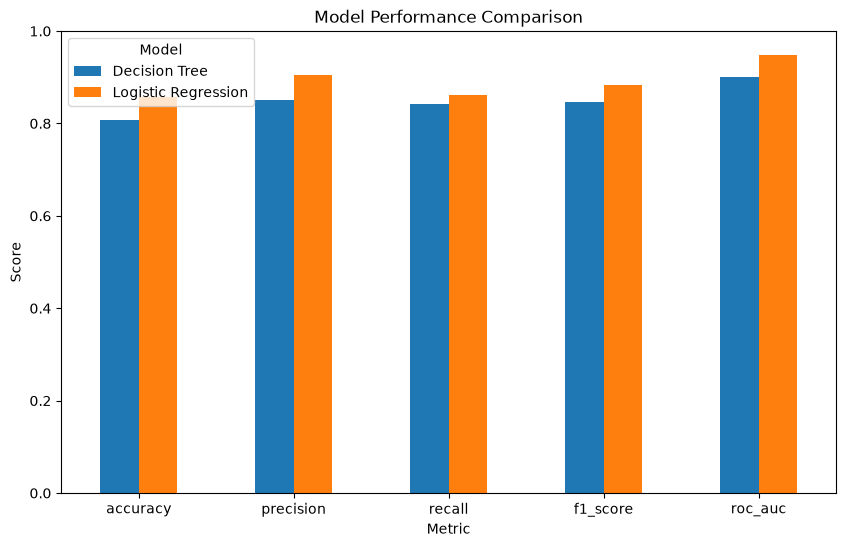

In [11]:
metric_comparison = comparison_df_rounded.set_index("model_name")[
    ["accuracy", "precision", "recall", "f1_score", "roc_auc"]
]

metric_comparison.T.plot(kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.show()

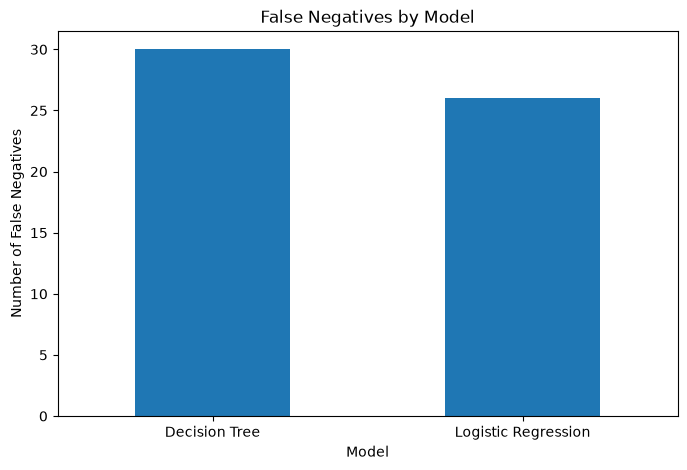

In [12]:
false_negative_comparison = comparison_df_rounded.set_index("model_name")[
    "false_negative"
]

false_negative_comparison.plot(kind="bar", figsize=(8, 5))

plt.title("False Negatives by Model")
plt.ylabel("Number of False Negatives")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.show()

### Visualization Observation

The model performance chart shows that Logistic Regression performs better than the Decision Tree across accuracy, precision, recall, F1-score, and ROC-AUC.

The false negative chart shows that Logistic Regression missed fewer truly vulnerable households than the Decision Tree. This is important because false negatives represent vulnerable households that the system failed to identify.

Based on these results, Logistic Regression is stronger for prediction performance, while the Decision Tree remains useful for simple rule-based explanation.

In [13]:
dt_cm = confusion_matrix(y_test, dt_pred)

dt_cm

array([[ 83,  28],
       [ 30, 159]])

In [14]:
lr_cm = confusion_matrix(y_test, lr_pred)

lr_cm

array([[ 94,  17],
       [ 26, 163]])

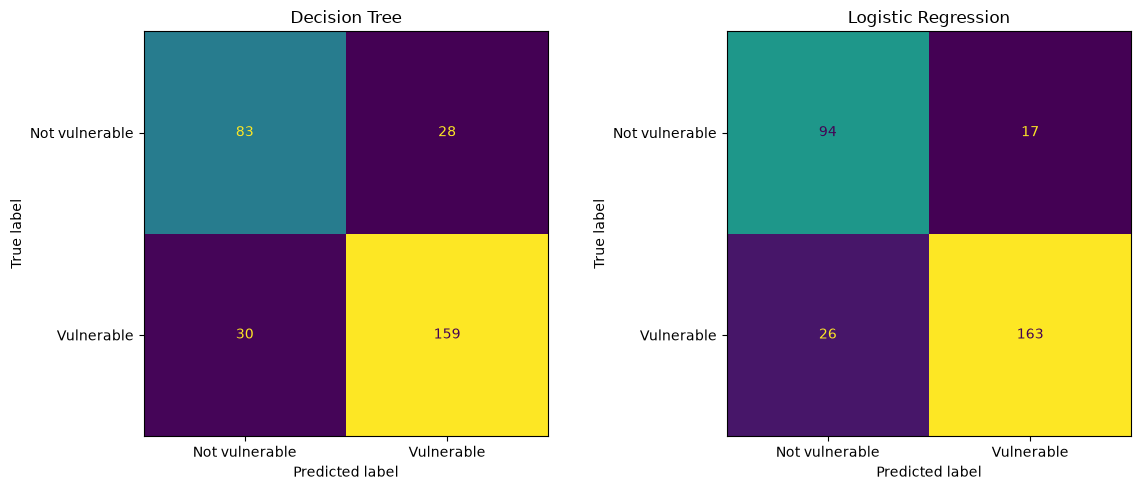

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

dt_display = ConfusionMatrixDisplay(
    confusion_matrix=dt_cm,
    display_labels=["Not vulnerable", "Vulnerable"]
)

lr_display = ConfusionMatrixDisplay(
    confusion_matrix=lr_cm,
    display_labels=["Not vulnerable", "Vulnerable"]
)

dt_display.plot(ax=axes[0], values_format="d", colorbar=False)
axes[0].set_title("Decision Tree")

lr_display.plot(ax=axes[1], values_format="d", colorbar=False)
axes[1].set_title("Logistic Regression")

plt.tight_layout()
plt.show()

### Confusion Matrix Comparison

The confusion matrices show the types of errors made by each model.

The Decision Tree correctly identified 159 vulnerable households and missed 30 vulnerable households.

Logistic Regression correctly identified 163 vulnerable households and missed 26 vulnerable households.

For this project, false negatives are especially important because they represent vulnerable households that were not detected. Logistic Regression performs better because it has fewer false negatives and more true positives.

## ROC-AUC Comparison

ROC-AUC measures how well a model separates vulnerable households from not vulnerable households using probability scores.

A higher ROC-AUC means the model is better at ranking vulnerable households with higher risk probabilities.

In [16]:
roc_auc_comparison = comparison_df_rounded[[
    "model_name",
    "roc_auc"
]]

roc_auc_comparison

,model_name,roc_auc
0,Decision Tree,0.9007
1,Logistic Regression,0.9484


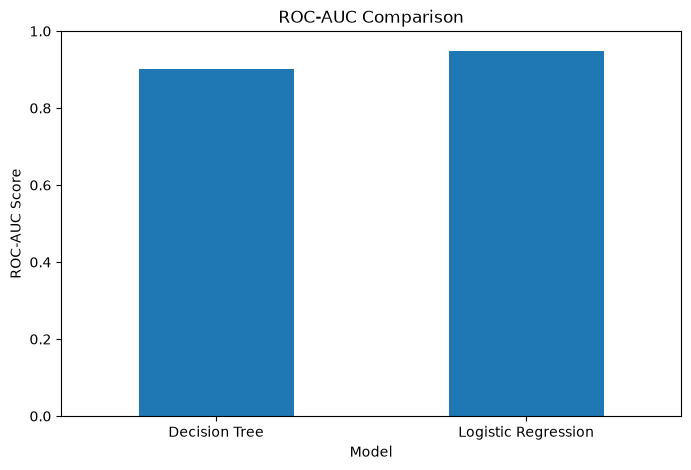

In [17]:
roc_auc_plot = comparison_df_rounded.set_index("model_name")["roc_auc"]

roc_auc_plot.plot(kind="bar", figsize=(8, 5))

plt.title("ROC-AUC Comparison")
plt.ylabel("ROC-AUC Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

### ROC-AUC Observation

Logistic Regression has a higher ROC-AUC score than the Decision Tree. This means Logistic Regression is better at separating vulnerable households from not vulnerable households using probability scores.

This is important because the AgriCredit Resilience system is intended to support risk-based decision-making. A model with stronger probability ranking is more useful for assigning vulnerability risk levels.

### ROC-AUC Observation

The ROC-AUC comparison shows that both models perform well, but Logistic Regression has the higher ROC-AUC score.

The Decision Tree achieved a ROC-AUC score of about 0.90, while Logistic Regression achieved about 0.95. This means Logistic Regression is better at ranking vulnerable households with higher probability scores.

This supports using Logistic Regression as the main prediction model for the final decision-support system.

## Interpretability Comparison

Model evaluation should not only focus on numerical performance. For this project, interpretability is also important because the system should support responsible financial decisions.

### Decision Tree Interpretability

The Decision Tree is easier to explain because it uses if-then rules. For example, the model can show that debt pressure, coping strategy score, crop damage, market access, and market pressure affect the prediction.

Strengths:

1. Easy to explain to non-technical users.
2. Shows clear decision paths.
3. Useful for explaining why a household may be classified as vulnerable.

Weaknesses:

1. Performance is lower than Logistic Regression in this project.
2. A deeper tree may become too complicated.
3. It may overfit if not controlled carefully.

### Logistic Regression Interpretability

Logistic Regression is also interpretable, but in a different way. It uses coefficients to show whether each feature increases or decreases the probability of financial vulnerability.

Strengths:

1. Gives vulnerability probability scores.
2. Coefficients show whether features increase or decrease vulnerability risk.
3. Performs better than Decision Tree in this project.
4. Useful for risk scoring and ranking households.

Weaknesses:

1. Coefficients can be harder to explain than tree rules.
2. Related features can make some coefficients look less intuitive.
3. It does not show simple if-then decision paths like a Decision Tree.

### Interpretability Conclusion

The Decision Tree is better for simple rule-based explanation. Logistic Regression is better for probability-based risk scoring.

Therefore, both models are useful:

- Decision Tree: supporting explanation model
- Logistic Regression: main prediction and probability model

In [18]:
comparison_summary = comparison_df_rounded.copy()

comparison_summary["recommended_use"] = [
    "Explainable rule-based support model",
    "Main probability-based prediction model",
]

comparison_summary

,model_name,accuracy,precision,recall,f1_score,roc_auc,true_negative,false_positive,false_negative,true_positive,recommended_use
0,Decision Tree,0.8067,0.8503,0.8413,0.8457,0.9007,83,28,30,159,Explainable rule-based support model
1,Logistic Regression,0.8567,0.9056,0.8624,0.8835,0.9484,94,17,26,163,Main probability-based prediction model


In [19]:
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

summary_path = REPORTS_DIR / "model_comparison_summary.csv"

comparison_summary.to_csv(summary_path, index=False)

summary_path

PosixPath('/Users/isaacaung/Desktop/agricredit-resilience/reports/model_comparison_summary.csv')

In [20]:
saved_summary = pd.read_csv(summary_path)

saved_summary

,model_name,accuracy,precision,recall,f1_score,roc_auc,true_negative,false_positive,false_negative,true_positive,recommended_use
0,Decision Tree,0.8067,0.8503,0.8413,0.8457,0.9007,83,28,30,159,Explainable rule-based support model
1,Logistic Regression,0.8567,0.9056,0.8624,0.8835,0.9484,94,17,26,163,Main probability-based prediction model


## Final Model Recommendation

Based on the evaluation results, Logistic Regression is recommended as the main model for the AgriCredit Resilience decision-support system.

Logistic Regression performed better than the Decision Tree across accuracy, precision, recall, F1-score, and ROC-AUC. It also produced fewer false negatives, meaning it missed fewer truly vulnerable households. This is important because the project focuses on identifying households that may need financial protection, support, or careful loan review.

Logistic Regression is also useful because it provides vulnerability probability scores. These probability scores can be converted into risk levels such as low risk, medium risk, and high risk.

However, the Decision Tree is still useful as a supporting explainability model. The Decision Tree provides simple if-then rules that are easier to explain to non-technical users.

Therefore, the final recommendation is:

- Use Logistic Regression as the main probability-based prediction model.
- Use Decision Tree as a supporting explanation model.

## Final Model Recommendation

Based on the evaluation results, Logistic Regression is recommended as the main model for the AgriCredit Resilience decision-support system.

Logistic Regression performed better than the Decision Tree across accuracy, precision, recall, F1-score, and ROC-AUC. It also produced fewer false negatives, meaning it missed fewer truly vulnerable households. This is important because the project focuses on identifying households that may need financial protection, support, or careful loan review.

Logistic Regression is also useful because it provides vulnerability probability scores. These probability scores can be converted into risk levels such as low risk, medium risk, and high risk.

However, the Decision Tree is still useful as a supporting explainability model. The Decision Tree provides simple if-then rules that are easier to explain to non-technical users.

Therefore, the final recommendation is:

- Use Logistic Regression as the main probability-based prediction model.
- Use Decision Tree as a supporting explanation model.